In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from jqdatasdk import *
from calc_fac import calc
from extract_fac import extract_fac
import plotly as py
import plotly.graph_objs as go
from plotly.offline import iplot, init_notebook_mode
import cufflinks
from plotly.subplots import make_subplots
from concurrent.futures import ProcessPoolExecutor
from backtrade import back_trade
cufflinks.go_offline(connected=True)
init_notebook_mode(connected=True)
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from  matplotlib.figure import Figure

d:\anaconda\envs\Yassin\lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.0.2) or chardet (5.0.0)/charset_normalizer (2.1.1) doesn't match a supported version!
  warnings.warn(


window.PlotlyConfig = {MathJaxConfig: 'local'};
 if (window.MathJax && window.MathJax.Hub && window.MathJax.Hub.Config) {window.MathJax.Hub.Config({SVG: {font: "STIX-Web"}});}
 if (typeof require !== 'undefined') {
 require.undef("plotly");
 requirejs.config({
 paths: {
 'plotly': ['https://cdn.plot.ly/plotly-2.12.1.min']
 }
 });
 require(['plotly'], function(Plotly) {
 window._Plotly = Plotly;
 });
 }

window.PlotlyConfig = {MathJaxConfig: 'local'};
 if (window.MathJax && window.MathJax.Hub && window.MathJax.Hub.Config) {window.MathJax.Hub.Config({SVG: {font: "STIX-Web"}});}
 if (typeof require !== 'undefined') {
 require.undef("plotly");
 requirejs.config({
 paths: {
 'plotly': ['https://cdn.plot.ly/plotly-2.12.1.min']
 }
 });
 require(['plotly'], function(Plotly) {
 window._Plotly = Plotly;
 });
 }

这里只回测了 2022 年 到 2023-05 的数据

因为分钟级别的数据太大了，下载也慢，算的也慢,我看研报里面给了一部分了，前面的部分就默认他是对的了，来看看后续的表现怎么样

研报 pdf 在附件

另外分钟级别的数据建议也不要找我要，我确实也不全…… 上传也太慢了。

研报的思路分成两个部分：

第一部分，投资者对大部分波动率不敏感，因此如果波动率显著上升但是收益率没有特别明显的变化，那么在未来这个股票会有对波动率定价的正向的 $\alpha$ 作为补偿。

第二部分，如果波动率特非常大，普通投资者的风险厌恶情绪会快速上升，而那些在高波动下提供风险补偿的股票（收益率高）展现出了非凡的能力，以至于投资者有理由相信，这种向好的势头将会长期持续。

不论是第一部分还是第二部分， 因子计算的过程都依赖于波动率，这里引入 “更优波动率”。

“更优波动率”的计算基于分钟数据，计算方法：获取 $[t-4,t]$ 分钟的高开低收共 20 个数据，对于这 20 个数据， 我们记其标准差为$S$, 均值为 $X$， 那么其 “更优波动率为” $(\frac{S}{X})^2$

我们计算每分钟的收益波动比，即使用 $t$ 分钟的收益率与 $t$ 分钟的“更优波动率”的比值，作为 $t$ 分钟的收益波动比。

求每天的 收益波动比 序列与 “更优波动率” 序列之间的协方差作为衡量投资者对波动变化反应不足程度的代理变量

后边的指标也是基于 两个协方差来计算的

第一个协方差是 全天除去开盘和收盘所有分钟的  收益波动率 和 更优波动率的协方差

第二个协方差是 全天除去开盘和收盘更优波动率超过均值+标准差的  收益波动率 和 更优波动率的协方差

在这里提前把两个协方差都算出来，记作 $fac_1, fac_2$

In [2]:
def login():
    auth('Name', 'Password')
    print(get_query_count())

In [3]:
login()
# calc("2022-01-04")

begin_date = "2020-01-01"
end_date= "2023-05-30"

auth success 
{'total': 500000, 'spare': 497819}


In [4]:
# #这个计算略相当慢，可以参考下我的配置，12代 i5 8门全开大概要跑四个小时
# trade_cal = get_trade_days(start_date=begin_date, end_date=end_date)
# trade_cal = [_.strftime("%Y-%m-%d") for _ in trade_cal]

# # 用多进程加速
# with ProcessPoolExecutor(max_workers=8) as pool:
#     pool.map(calc, trade_cal)

In [5]:
df = extract_fac("2022-01-01", "2023-05-30")
df.to_pickle("fac3.pkl")
df.head(10)

,code,fac1,fac2,date
0,000001.XSHE,1.151596,0.997808,2022-01-04
1,000002.XSHE,1.308784,0.892495,2022-01-04
2,000004.XSHE,1.396606,1.486718,2022-01-04
3,000005.XSHE,1.750752,1.794865,2022-01-04
4,000006.XSHE,1.623199,1.174106,2022-01-04
5,000007.XSHE,1.598868,1.074308,2022-01-04
6,000008.XSHE,1.523119,1.871387,2022-01-04
7,000009.XSHE,1.370319,0.761169,2022-01-04
8,000010.XSHE,1.937399,0.955637,2022-01-04
9,000011.XSHE,1.602476,1.681485,2022-01-04


In [6]:
def show(df, Name, Type = 0):
    '''
        Type = 0 时 用 plotly 绘图
        Type = 1 时 用 matplotlib 绘图
    '''
    if Type == 0:
        df["date"] = pd.to_datetime(df["date"])
        trace0 = go.Scatter(x = df["date"], y = df["ret_0"], name = "group_0")
        trace1 = go.Scatter(x = df["date"], y = df["ret_1"], name = "group_1")
        trace2 = go.Scatter(x = df["date"], y = df["ret_2"], name = "group_2")
        trace3 = go.Scatter(x = df["date"], y = df["ret_3"], name = "group_3")
        trace4 = go.Scatter(x = df["date"], y = df["ret_4"], name = "group_4")
        trace5 = go.Scatter(x = df["date"], y = df["ret_5"], name = "group_5")
        trace6 = go.Scatter(x = df["date"], y = df["ret_6"], name = "group_6")
        trace7 = go.Scatter(x = df["date"], y = df["ret_7"], name = "group_7")
        trace8 = go.Scatter(x = df["date"], y = df["ret_8"], name = "group_8")
        trace9 = go.Scatter(x = df["date"], y = df["ret_9"], name = "group_9")

        fig = make_subplots(specs=[[{'secondary_y': True}]])
        
        data = [trace0, trace1, trace2, trace3, trace4, trace5, trace6, trace7, trace8, trace9]
        fig.add_traces(data)

        fig.add_trace(
            go.Scatter(x=df["date"], y=df["ret_0"] / df["ret_9"], name="多空差异"),
            secondary_y=True,
        )
        
        fig.update_layout(
            title = Name, 
            xaxis_title = "Date",
            yaxis_title = "Return",
        )

        fig.show()
    else:
        fig = Figure(figsize=(25, 9), dpi=100)
        plt.subplot(2,1,1)
        for i in range(0, 10):
            plt.plot(df["date"], df["ret_{}".format(i)], label = "group_{}".format(i))
        plt.legend()
        plt.title(Name)
        plt.subplot(2,1,2)
        plt.plot(df["date"], df["ret_0"] / df["ret_9"], label = "call_put_diff")
        plt.legend()
        plt.show()

首先来做一下第一个因子 “灾后重建” 因子

使用的是全天的 收益波动率 和 更优波动率的 协方差，作为一天的 灾后重建的股票的代理变量

滚动 20 天的代理变量的 均值 和 标准差 分别记为“月均重建” 和 “月稳重建”， 等权合成（二者标准化后求和）后得到的因子记作 “灾后重建因子”


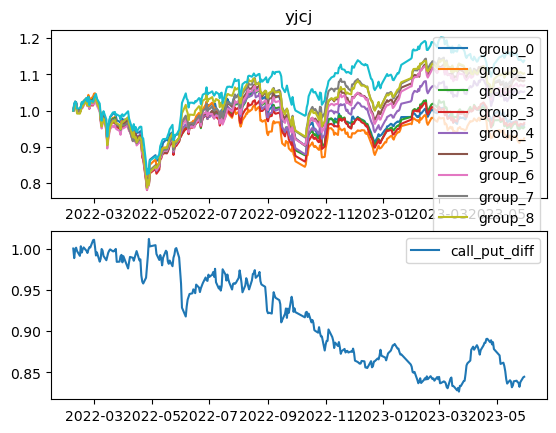

In [7]:

df["yjcj"] = df.groupby("code", as_index = False)["fac1"].apply(lambda x:x.rolling(20).mean())

fac1_df = back_trade(df, "yjcj")
show(fac1_df, "yjcj", Type = 1)

看起来已经不太好用了

理论上应该是因子值越小表现越好，这里来看表现很一般了

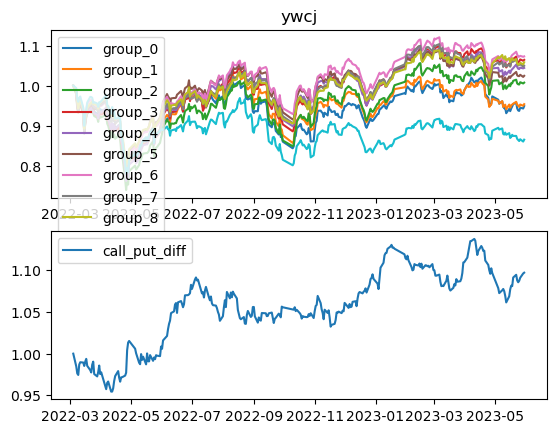

In [8]:
df["ywcj"] = df.groupby("code", as_index = False)["fac1"].apply(lambda x:x.rolling(20).std())

fac1_df = back_trade(df, "ywcj")
show(fac1_df, "ywcj", Type = 1)

多空收益还可以，但是第 0 组的收益也没多好

第九组表现的最差倒是真的 TAT

最后来合成一下灾后重建因子

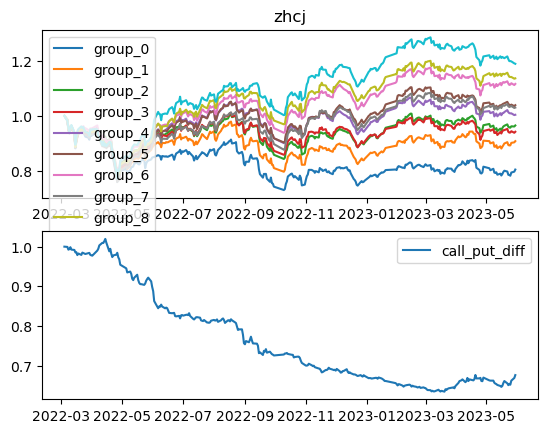

In [9]:
def z_score(g):
    return (g - g.mean()) / g.std()

df["yjcj_z"] = df.groupby("code")["yjcj"].apply(z_score)
df["ywcj_z"] = df.groupby("code")["ywcj"].apply(z_score)
df["zhcj"] = df["yjcj_z"] + df["ywcj_z"]

fac1_df = back_trade(df, "zhcj")
show(fac1_df, "zhcj", Type = 1)

我一度以为自己的代码写错了，说好的因子值越小越好呢……

这哪是灾后重建，整个一个推倒重来了

如果有大神发现了问题所在请马上 @ 我，谢谢

接下来我们考察勇攀高峰因子,注意这是一个正向指标，因子值越大越好。

首先是月均勇攀因子

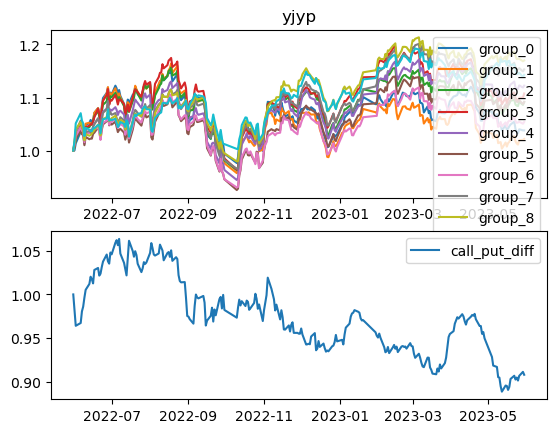

In [13]:
df["yjyp"] = df.groupby("code", as_index = False)["fac2"].apply(lambda x:x.rolling(20).mean())

fac2_df = back_trade(df, "yjyp")
show(fac2_df, "yjyp", Type = 1)

多空收益尚可，但是分组效应不明显

接下来计算月稳勇攀因子

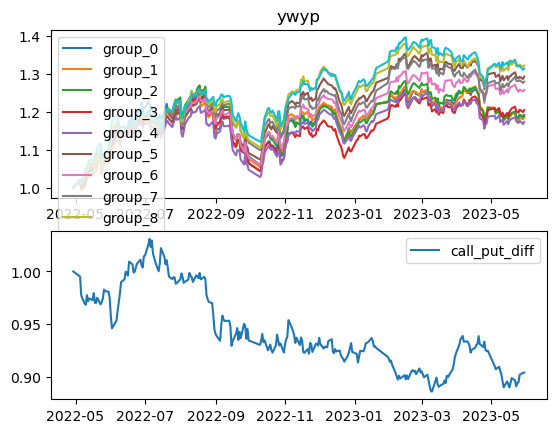

In [11]:
df["ywyp"] = df.groupby("code", as_index = False)["fac2"].apply(lambda x:x.rolling(20).std())

fac2_df = back_trade(df, "ywyp")
show(fac2_df, "ywyp", Type = 1)

比月均勇攀的效果好，也符合常规认知吧，月稳勇攀高说明持续有资金做多，类似于分时情况的波动率动量因子了

最后将表现较为稳定的强势半潮汐因子和弱势稳定半潮汐因子进行等权合并，组成最后的 $fin_{fac}$

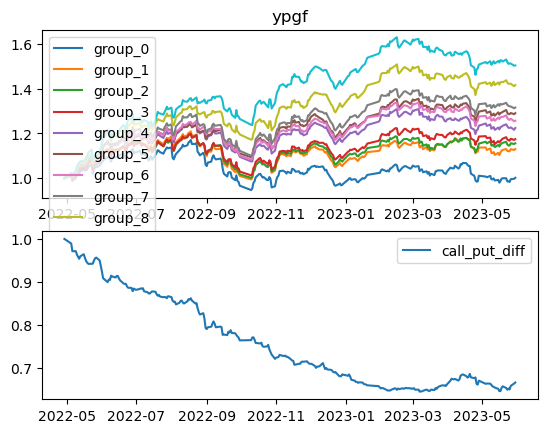

In [12]:
def z_score(g):
    return (g - g.mean()) / g.std()

df["yjyp_z"] = df.groupby("code")["yjyp"].apply(z_score)
df["ywyp_z"] = df.groupby("code")["ywyp"].apply(z_score)

df["ypgf"] = df["yjyp_z"] + df["ywyp_z"]
fac5_df = back_trade(df, "ypgf")
show(fac5_df, "ypgf", Type = 1)

多空收益几乎拉成一条直线，分组也比较显著了，非常优秀的因子